# Домашная работа №2: Поиск нестандартных криптовалют: кластеризация финансовых рядов

**Студент:** Сизиков Константин.

**Задача.** Флагманская криптовалюта — Bitcoin, и динамика цен подавляющего большинства
альткоинов почти повторяет его движение. Нужно найти криптовалюты, которые **не попадают
в кластер биткоина** на трёх разных временных горизонтах:

| Горизонт | Частота | Длина ряда |
|---|---|---|
| последние 30 дней | дневная | 31 точка |
| последние 3 дня | часовая | 73 точки |
| последний час | минутная | 61 точка |

**План работы**

1. Получение списка всех торгующихся монет через `cryptocompare.get_coin_list(format=True)`.
2. Загрузка цен закрытия по трём горизонтам.
3. EDA, выравнивание рядов по общей временной сетке, переход к масштабно-инвариантному
   представлению (лог-доходности + z-нормировка).
4. «Классическая» кластеризация: `KMeans`, иерархическая на корреляционной метрике, `DBSCAN`.
5. Кластеризация на основе **DTW**: `TimeSeriesKMeans(metric="dtw")` и агломеративная
   кластеризация на предпосчитанной матрице DTW-расстояний.
6. Сводка по 3 горизонтам × 5 методам, консенсусный рейтинг «непохожести на BTC».
7. Выводы.

In [1]:
import gzip
import json
import os
import time
import warnings
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from scipy.spatial.distance import squareform
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data"
DATA_DIR.mkdir(exist_ok=True)

REF = "BTC"          # эталонная монета, вокруг кластера которой всё строится
CURRENCY = "USD"     # котируемая валюта

# Три временных горизонта из условия задачи
HORIZONS = {
    "30d_daily": {
        "title": "30 дней / дневная частота",
        "unit": "day",
        "limit": 30,            # cryptocompare вернёт limit + 1 точку
        "binance_interval": "1d",
    },
    "3d_hourly": {
        "title": "3 дня / часовая частота",
        "unit": "hour",
        "limit": 3 * 24,
        "binance_interval": "1h",
    },
    "1h_minutely": {
        "title": "1 час / минутная частота",
        "unit": "minute",
        "limit": 60,
        "binance_interval": "1m",
    },
}

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 4.5)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 12

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 50)

print("Рабочая директория:", PROJECT_DIR)
print("Кэш данных:", DATA_DIR)

Рабочая директория: /home/ubuntu/projects/ml/machine_learning_expert/hw_02_2
Кэш данных: /home/ubuntu/projects/ml/machine_learning_expert/hw_02_2/data


---
## 1. Источник данных

### 1.1. Список всех торгующихся криптовалют

Используем библиотеку `cryptocompare` ровно так, как требует условие:
`cryptocompare.get_coin_list(format=True)` возвращает список тикеров всех монет,
известных сервису.

> **Замечание по состоянию API.** Эндпоинт со списком монет
> (`www.cryptocompare.com/api/data/coinlist`) по-прежнему открыт и работает без ключа,
> а вот исторические котировки (`min-api.cryptocompare.com/data/v2/histo*`) после перехода
> сервиса под CoinDesk отдают `401 API key required`. Поэтому ниже реализованы
> **два источника котировок**: основной — `cryptocompare` (включается автоматически,
> если в переменной окружения `CRYPTOCOMPARE_API_KEY` или в файле `cryptocompare_api_key.txt`
> есть ключ), и резервный — публичное зеркало биржевого API Binance
> (`data-api.binance.vision`), которое отдаёт те же цены закрытия (OHLCV) с интервалами
> `1d` / `1h` / `1m` без ключа. Логика анализа от источника не зависит.

In [2]:
import cryptocompare

# --- ключ API (если он есть) ---
key_file = PROJECT_DIR / "cryptocompare_api_key.txt"
API_KEY = os.getenv("CRYPTOCOMPARE_API_KEY") or (
    key_file.read_text().strip() if key_file.exists() else None
)
if API_KEY:
    os.environ["CRYPTOCOMPARE_API_KEY"] = API_KEY   # библиотека читает переменную окружения
    print("CryptoCompare API key: найден")
else:
    print("CryptoCompare API key: не найден")

print("Версия библиотеки cryptocompare:", getattr(cryptocompare, "__version__", "0.7.6"))

CryptoCompare API key: не найден
Версия библиотеки cryptocompare: 0.7.6


In [3]:
COINLIST_CACHE = DATA_DIR / "cryptocompare_coinlist.json.gz"

if COINLIST_CACHE.exists():
    with gzip.open(COINLIST_CACHE, "rt", encoding="utf-8") as f:
        coinlist_raw = json.load(f)
    print("Список монет загружен из кэша:", COINLIST_CACHE.name)
else:
    t0 = time.time()
    coinlist_raw = cryptocompare.get_coin_list(format=False)   # ~15 МБ, полные метаданные
    with gzip.open(COINLIST_CACHE, "wt", encoding="utf-8") as f:
        json.dump(coinlist_raw, f)
    print(f"Список монет скачан с CryptoCompare за {time.time() - t0:.1f} c")

# ровно то, что возвращает cryptocompare.get_coin_list(format=True)
coin_symbols = list(coinlist_raw.keys())

print(f"Всего торгующихся криптовалют в списке CryptoCompare: {len(coin_symbols)}")
print("Первые 20 тикеров:", coin_symbols[:20])
assert len(coin_symbols) > 5600, "ожидалось больше 5600 монет"

Список монет загружен из кэша: cryptocompare_coinlist.json.gz
Всего торгующихся криптовалют в списке CryptoCompare: 20110
Первые 20 тикеров: ['BTC', 'ETH', 'LTC', 'DASH', 'XMR', 'NXT', 'ETC', 'DOGE', 'BTS', 'DGB', 'XRP', 'BTCD', 'PPC', 'CRAIG', 'XBS', 'XPY', 'PRC', 'YBC', 'DANK', 'GIVE']


In [4]:
# Компактная таблица метаданных по монетам
coin_meta = (
    pd.DataFrame(
        [
            {
                "Symbol": sym,
                "CoinName": rec.get("CoinName"),
                "FullName": rec.get("FullName"),
                "SortOrder": pd.to_numeric(rec.get("SortOrder"), errors="coerce"),
                "IsTrading": rec.get("IsTrading"),
                "AssetLaunchDate": rec.get("AssetLaunchDate"),
            }
            for sym, rec in coinlist_raw.items()
        ]
    )
    .set_index("Symbol")
    .sort_values("SortOrder")
)

print("Размер таблицы метаданных:", coin_meta.shape)
coin_meta.head(10)

Размер таблицы метаданных: (20110, 5)


,CoinName,FullName,SortOrder,IsTrading,AssetLaunchDate
Symbol,,,,,
BTC,Bitcoin,Bitcoin (BTC),1,None,None
ETH,Ethereum,Ethereum (ETH),2,None,None
LTC,Litecoin,Litecoin (LTC),3,None,None
DASH,Dash,Dash (DASH),4,None,None
XMR,Monero,Monero (XMR),5,None,None
NXT,Nxt,Nxt (NXT),6,None,None
ETC,Ethereum Classic,Ethereum Classic (ETC),7,None,None
DOGE,Dogecoin,Dogecoin (DOGE),8,None,None
ZEC,ZCash,ZCash (ZEC),9,None,None


### 1.2. Вселенная тикеров для загрузки котировок

Список CryptoCompare содержит десятки тысяч символов, но большинство из них — «мёртвые»
монеты без ликвидного рынка: у них либо вообще нет котировок, либо цена стоит на месте
годами. Кластеризовать такой мусор бессмысленно, поэтому вселенную сужаем до монет,

* которые присутствуют в списке CryptoCompare (требование задания), **и**
* по которым есть живой рынок к доллару с ненулевым оборотом за последние 24 часа.

Список ликвидных пар и их обороты берём из `/api/v3/ticker/24hr`. Если работает
основной источник (есть ключ CryptoCompare), вселенная всё равно нужна — иначе пришлось бы
делать 20 000 запросов, из которых 97 % вернут пустоту.

In [5]:
BINANCE_API = "https://data-api.binance.vision/api/v3"
UNIVERSE_CACHE = DATA_DIR / "universe.csv"


def build_universe(coin_symbols, quote="USDT", max_coins=None) -> pd.DataFrame:
    """Ликвидные пары к доллару, пересечённые со списком монет CryptoCompare."""
    if UNIVERSE_CACHE.exists():
        uni = pd.read_csv(UNIVERSE_CACHE)
        print("Вселенная загружена из кэша:", UNIVERSE_CACHE.name)
        return uni

    tickers = requests.get(f"{BINANCE_API}/ticker/24hr", timeout=180).json()
    rows = [
        (t["symbol"], t["symbol"][: -len(quote)], float(t["quoteVolume"]), float(t["lastPrice"]))
        for t in tickers
        if t["symbol"].endswith(quote) and float(t["quoteVolume"]) > 0
    ]
    uni = pd.DataFrame(rows, columns=["symbol", "base", "quote_volume_24h", "last_price"])
    uni = (
        uni[uni["base"].isin(set(coin_symbols))]
        .sort_values("quote_volume_24h", ascending=False)
        .reset_index(drop=True)
    )
    if max_coins:
        uni = uni.head(max_coins)
    uni.to_csv(UNIVERSE_CACHE, index=False)
    return uni


universe = build_universe(coin_symbols)
tickers = universe["base"].tolist()

print(f"Монет в рабочей вселенной: {len(universe)}  (BTC внутри: {REF in set(tickers)})")
display(universe.head(10))

Вселенная загружена из кэша: universe.csv
Монет в рабочей вселенной: 576  (BTC внутри: True)


,symbol,base,quote_volume_24h,last_price
0,USDCUSDT,USDC,2.896987e+09,1.00016
1,BTCUSDT,BTC,1.091475e+09,77625.13000
2,ETHUSDT,ETH,9.207914e+08,2492.07000
3,XRPUSDT,XRP,3.360186e+08,1.40990
4,ZECUSDT,ZEC,2.549765e+08,1146.91000
5,SOLUSDT,SOL,2.223558e+08,101.22000
6,USD1USDT,USD1,1.689519e+08,0.99982
7,BNBUSDT,BNB,9.865130e+07,721.00000
8,RLUSDUSDT,RLUSD,5.697051e+07,1.00020
9,LSKUSDT,LSK,5.643535e+07,0.38570


---
## 2. Загрузка цен закрытия по трём горизонтам

Ниже — два взаимозаменяемых загрузчика с одинаковым интерфейсом
«тикер + горизонт → `pd.Series` цен закрытия».

* `fetch_cryptocompare` — вызовы из условия задачи:
  `get_historical_price_day / _hour / _minute`.
  *Нюанс:* в актуальной версии библиотеки параметр называется `currency`, а не `curr`
  (в задании указано старое имя).
* `fetch_binance` — резервный источник, поле `close` свечей `1d` / `1h` / `1m`.

Результат каждой загрузки кэшируется в `data/prices_<горизонт>.csv`, чтобы повторный
запуск ноутбука не дёргал сеть.

In [6]:
def fetch_cryptocompare(ticker: str, horizon: dict) -> pd.Series | None:
    """Цены закрытия через библиотеку cryptocompare (основной источник)."""
    fn = {
        "day": cryptocompare.get_historical_price_day,
        "hour": cryptocompare.get_historical_price_hour,
        "minute": cryptocompare.get_historical_price_minute,
    }[horizon["unit"]]
    try:
        rows = fn(ticker, currency=CURRENCY, limit=horizon["limit"])
    except Exception:
        return None
    if not rows:
        return None
    s = pd.Series(
        [float(r["close"]) for r in rows],
        index=pd.to_datetime([r["time"] for r in rows], unit="s", utc=True),
        name=ticker,
    )
    return s


_session = requests.Session()


def fetch_binance(ticker: str, horizon: dict, retries: int = 4) -> pd.Series | None:
    """Цены закрытия через публичное зеркало биржевого API (резервный источник)."""
    params = {
        "symbol": f"{ticker}USDT",
        "interval": horizon["binance_interval"],
        "limit": horizon["limit"] + 1,
    }
    for attempt in range(retries):
        try:
            resp = _session.get(f"{BINANCE_API}/klines", params=params, timeout=25)
            if resp.status_code == 200:
                candles = resp.json()
                if not candles:
                    return None
                return pd.Series(
                    [float(c[4]) for c in candles],                       # close
                    index=pd.to_datetime([c[0] for c in candles], unit="ms", utc=True),
                    name=ticker,
                )
        except Exception:
            pass
        time.sleep(1 + attempt)
    return None

In [7]:
def probe_source() -> str:
    """Проверяем, доступен ли основной источник; иначе переключаемся на резервный."""
    if API_KEY:
        probe = fetch_cryptocompare(REF, HORIZONS["30d_daily"])
        if probe is not None and probe.notna().sum() > 5:
            return "cryptocompare"
        print("CryptoCompare не отдал данные несмотря на ключ — переключаюсь на резерв.")
    else:
        print("Ключа CryptoCompare нет: исторические котировки их API отдаёт только по ключу.")
    return "binance"


SOURCE = probe_source()
FETCH = {"cryptocompare": fetch_cryptocompare, "binance": fetch_binance}[SOURCE]
print("Используемый источник котировок:", SOURCE)

Ключа CryptoCompare нет: исторические котировки их API отдаёт только по ключу.
Используемый источник котировок: binance


In [8]:
def download_horizon(key: str, tickers: list[str], workers: int = 6) -> pd.DataFrame:
    """Скачивает цены закрытия по всем тикерам для одного горизонта (с кэшем на диске)."""
    cache = DATA_DIR / f"prices_{key}.csv"
    if cache.exists():
        df = pd.read_csv(cache, index_col=0, parse_dates=True)
        print(f"[{key}] из кэша: {df.shape[1]} монет, {df.shape[0]} меток времени")
        return df

    horizon = HORIZONS[key]
    t0 = time.time()
    series = {}

    def job(ticker):
        return FETCH(ticker, horizon)

    with ThreadPoolExecutor(workers) as pool:
        for s in tqdm(pool.map(job, tickers), total=len(tickers), desc=key):
            if s is not None and len(s) >= horizon["limit"] - 1:
                series[s.name] = s

    df = pd.DataFrame(series).sort_index()
    df.to_csv(cache)
    print(f"[{key}] скачано {df.shape[1]} монет за {time.time() - t0:.0f} c")
    return df


raw_prices = {key: download_horizon(key, tickers) for key in HORIZONS}

[30d_daily] из кэша: 576 монет, 1182 меток времени
[3d_hourly] из кэша: 576 монет, 4525 меток времени


[1h_minutely] из кэша: 576 монет, 3844 меток времени


In [9]:
summary_raw = pd.DataFrame(
    {
        key: {
            "монет получено": df.shape[1],
            "меток времени (объединение)": df.shape[0],
            "заполненность объединённой сетки, %": round(100 * df.notna().mean().mean(), 1),
            "BTC получен": REF in df.columns,
        }
        for key, df in raw_prices.items()
    }
).T
summary_raw.index = [HORIZONS[k]["title"] for k in summary_raw.index]
summary_raw

,монет получено,меток времени (объединение),"заполненность объединённой сетки, %",BTC получен
30 дней / дневная частота,576,1182,2.6,True
3 дня / часовая частота,576,4525,1.6,True
1 час / минутная частота,576,3844,1.6,True


---
## 3. EDA и подготовка признаков

### 3.1. Что не так с «сырой» матрицей цен

Число меток времени в объединении заметно больше длины ряда: часть пар на бирже
фактически мертва — их последние свечи датированы месяцами и годами назад, поэтому
их временная сетка не совпадает с актуальной. Приводим всё к **общей сетке BTC**:

1. Берём временную сетку эталонной монеты (BTC) — это и есть «последние 30 дней / 3 дня / час».
2. Переиндексируем на неё все монеты.
3. Оставляем монеты с покрытием ≥ 90 % точек (остальные — делистинг/стухшая ликвидность),
   оставшиеся одиночные пропуски закрываем `ffill`/`bfill`.
4. Отбрасываем ряды с неположительными ценами (логарифм не определён).

In [10]:
MIN_COVERAGE = 0.90


def align_prices(raw: pd.DataFrame, ref: str = REF, min_coverage: float = MIN_COVERAGE):
    """Выравнивает все монеты на временную сетку эталона и чистит ряды."""
    grid = raw[ref].dropna().index
    px = raw.reindex(grid)

    coverage = px.notna().mean()
    dropped_stale = sorted(coverage[coverage < min_coverage].index)
    px = px.loc[:, coverage >= min_coverage].ffill().bfill()

    bad_price = sorted(px.columns[~(px > 0).all()])
    px = px.loc[:, (px > 0).all()]

    report = {
        "точек в сетке": len(grid),
        "монет на входе": raw.shape[1],
        "отброшено (покрытие < %d%%)" % int(min_coverage * 100): len(dropped_stale),
        "отброшено (цена <= 0)": len(bad_price),
        "монет на выходе": px.shape[1],
        "начало окна": str(grid[0]),
        "конец окна": str(grid[-1]),
    }
    return px, report


prices, align_report = {}, {}
for key, raw in raw_prices.items():
    prices[key], align_report[key] = align_prices(raw)

report_df = pd.DataFrame(align_report).T
report_df.index = [HORIZONS[k]["title"] for k in report_df.index]
report_df

,точек в сетке,монет на входе,отброшено (покрытие < 90%),отброшено (цена <= 0),монет на выходе,начало окна,конец окна
30 дней / дневная частота,31,576,167,0,409,2026-08-16 00:00:00+00:00,2026-09-15 00:00:00+00:00
3 дня / часовая частота,73,576,167,0,409,2026-09-12 05:00:00+00:00,2026-09-15 05:00:00+00:00
1 час / минутная частота,61,576,167,0,409,2026-09-15 04:08:00+00:00,2026-09-15 05:08:00+00:00


### 3.2. Представление ряда: лог-доходности + z-нормировка

Кластеризовать **сырые цены** бессмысленно: расстояние между рядами будет определяться
масштабом цены, и BTC ($\sim$десятки тысяч долларов) окажется в кластере из одного себя,
а весь остальной рынок — в другом. Это не «непохожесть динамики», а разница в номинале.

Поэтому переходим к масштабно-инвариантному представлению:

$$r_t = \log P_t - \log P_{t-1}, \qquad z_t = \frac{r_t - \bar r}{\sigma_r}$$

* логарифмическая доходность убирает уровень цены;
* z-нормировка убирает разницу в волатильности, оставляя только **форму** совместного движения.

На z-нормированных доходностях евклидово расстояние монотонно связано с корреляцией:
$\|z_a - z_b\|^2 = 2T\,(1 - \rho_{ab})$ — то есть `KMeans` на таких признаках
кластеризует ровно по «степени со-движения с рынком», что нам и нужно.

Для DTW (раздел 5) нужна **траектория**, а не приращения, поэтому там используется
z-нормированный ряд лог-цен.

In [11]:
def make_features(px: pd.DataFrame):
    """Из матрицы цен строит все нужные представления."""
    logret = np.log(px).diff().iloc[1:]                       # лог-доходности, T-1 x N
    sigma = logret.std(ddof=0).replace(0.0, np.nan)
    z_ret = ((logret - logret.mean()) / sigma).fillna(0.0)    # z-нормированные доходности

    logpx = np.log(px)
    z_px = ((logpx - logpx.mean()) / logpx.std(ddof=0).replace(0.0, np.nan)).fillna(0.0)

    return {
        "px": px,
        "logret": logret,
        "z_ret": z_ret,            # признаки для «классической» кластеризации
        "z_px": z_px,              # траектории для DTW
        "X": z_ret.T.values,       # (n_coins, T-1)
        "P": z_px.T.values[:, :, None],   # (n_coins, T, 1) — формат tslearn
        "coins": np.array(z_ret.columns),
    }


feat = {key: make_features(px) for key, px in prices.items()}

for key, f in feat.items():
    flat = int((f["logret"].std(ddof=0) == 0).sum())
    print(f'{HORIZONS[key]["title"]:<28} X={f["X"].shape}  P={f["P"].shape}  '
          f'рядов с нулевой волатильностью: {flat}')

30 дней / дневная частота    X=(409, 30)  P=(409, 31, 1)  рядов с нулевой волатильностью: 0
3 дня / часовая частота      X=(409, 72)  P=(409, 73, 1)  рядов с нулевой волатильностью: 0
1 час / минутная частота     X=(409, 60)  P=(409, 61, 1)  рядов с нулевой волатильностью: 0


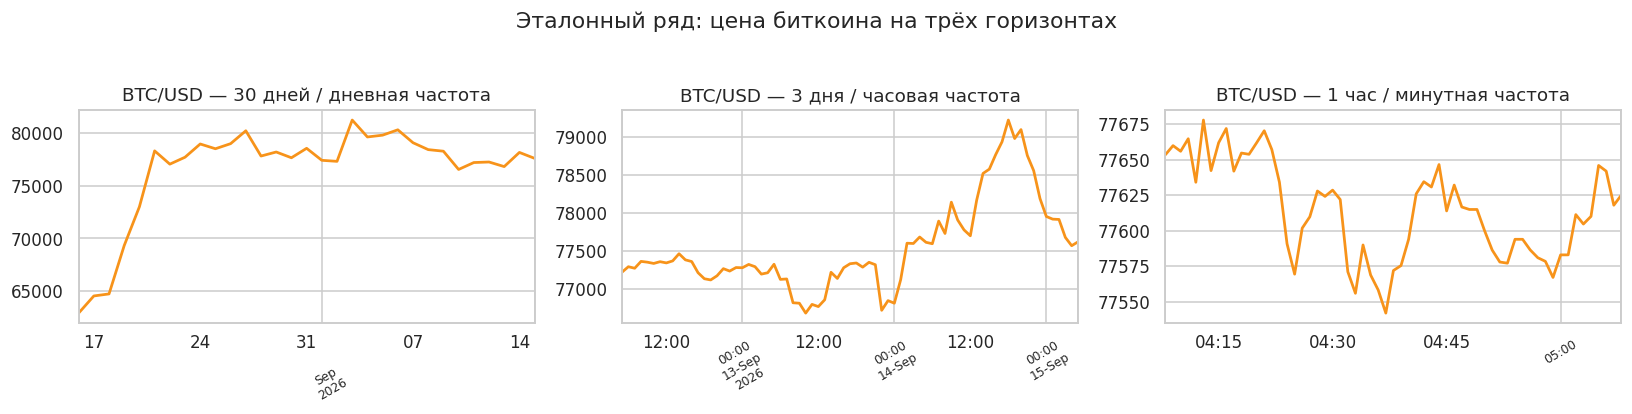

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
for ax, (key, f) in zip(axes, feat.items()):
    f["px"][REF].plot(ax=ax, color="#F7931A", lw=1.8)
    ax.set_title(f'BTC/USD — {HORIZONS[key]["title"]}')
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30, labelsize=8)
fig.suptitle("Эталонный ряд: цена биткоина на трёх горизонтах", y=1.04)
plt.tight_layout()
plt.show()

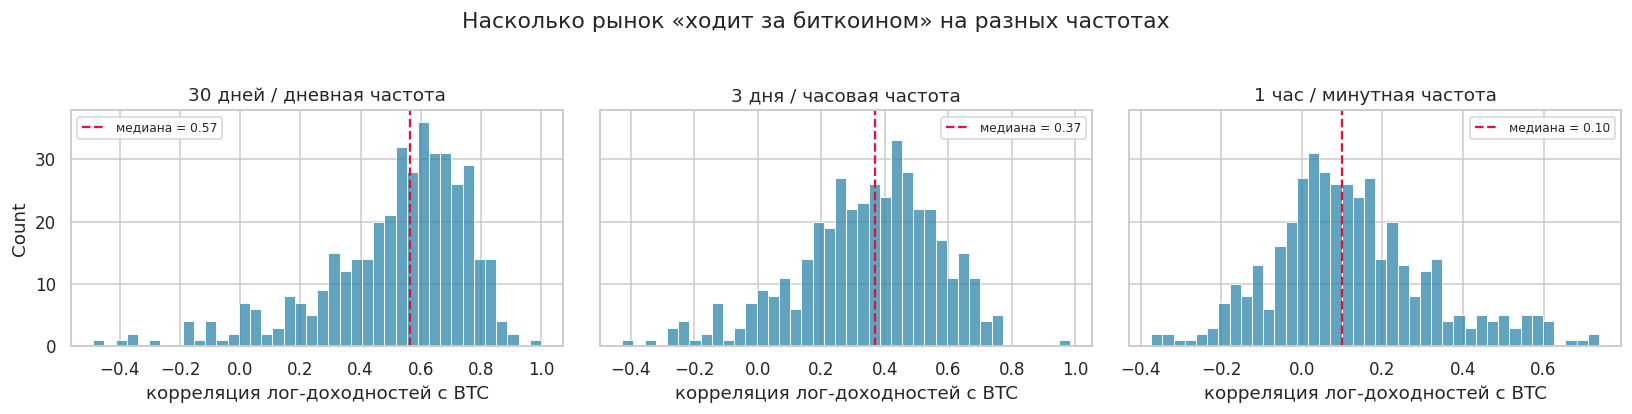

,30d_daily,3d_hourly,1h_minutely
count,408.000,408.000,408.000
mean,0.514,0.345,0.123
std,0.245,0.222,0.197
min,-0.488,-0.426,-0.374
25%,0.401,0.218,-0.004
50%,0.566,0.368,0.100
75%,0.685,0.499,0.224
max,1.000,0.983,0.738


In [13]:
corr_btc = pd.DataFrame(
    {key: f["logret"].corrwith(f["logret"][REF]).drop(REF) for key, f in feat.items()}
)

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6), sharey=True)
for ax, key in zip(axes, HORIZONS):
    sns.histplot(corr_btc[key], bins=40, ax=ax, color="#2E86AB", edgecolor="white")
    ax.axvline(corr_btc[key].median(), color="crimson", ls="--",
               label=f"медиана = {corr_btc[key].median():.2f}")
    ax.set_title(HORIZONS[key]["title"])
    ax.set_xlabel("корреляция лог-доходностей с BTC")
    ax.legend(fontsize=8)
fig.suptitle("Насколько рынок «ходит за биткоином» на разных частотах", y=1.04)
plt.tight_layout()
plt.show()

display(corr_btc.describe().round(3))

Картина уже говорит о многом: чем выше частота наблюдений, тем слабее связь с биткоином.
На дневных данных медианная корреляция с BTC высокая (общий рыночный фактор виден
невооружённым глазом), на часовых — заметно ниже, а на минутных доходностях она
практически исчезает: на этом масштабе доминирует микроструктурный шум конкретного
инструмента, а не общерыночное движение. Это ключ к интерпретации результатов
кластеризации ниже.

---
## 4. «Классическая» кластеризация

Три независимых метода, все работают с одним и тем же понятием близости
(со-движение доходностей), но по-разному:

| Метод | Пространство | Что ловит |
|---|---|---|
| `KMeans` | z-нормированные доходности, евклид | шаровидные кластеры вокруг «рыночного фактора» |
| Иерархическая (average linkage) | матрица $d_{ab} = 1 - \rho_{ab}$ | вложенную структуру, устойчива к кластерам разного размера |
| `DBSCAN` | та же матрица расстояний | плотное «ядро рынка» + явные выбросы (шум, метка `-1`) |

Число кластеров $k$ подбираем по silhouette score.

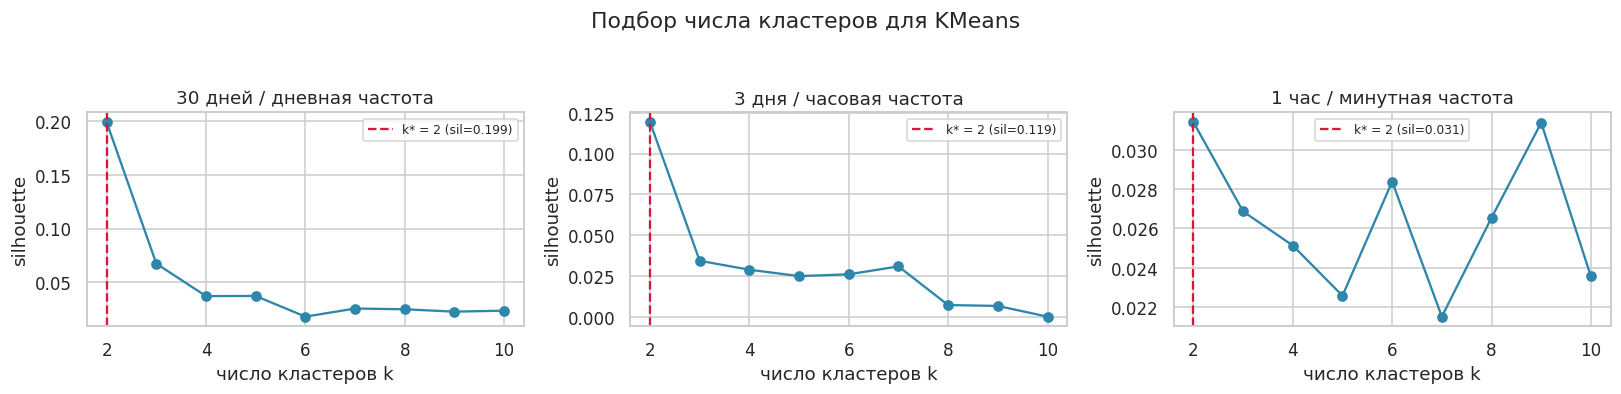

30 дней / дневная частота            3 дня / часовая частота             1 час / минутная частота            
                  silhouette    inertia              silhouette     inertia               silhouette     inertia
k                                                                                                               
2                     0.1988  6790.4759                  0.1192  19825.4564                   0.0314  22065.9442
3                     0.0674  6553.8290                  0.0344  19012.6807                   0.0269  21629.6361
4                     0.0372  6376.0699                  0.0289  18616.3110                   0.0251  21297.5045
5                     0.0374  6194.8390                  0.0250  18371.4017                   0.0226  21003.5940
6                     0.0182  6054.2375                  0.0261  18096.5885                   0.0284  20749.8735
7                     0.0257  5956.3636                  0.0310  17952.7563                   0.0215  20488.9330
8                     0.0250  5799.9325                  0.0073  17787.7105                   0.0265  20347.9639
9                     0.0228  5730.0764                  0.0068  17649.2838                   0.0314  20176.5103
10                    0.0237  5637.1971                  0.0002  17461.2138                   0.0236  20009.7724

In [14]:
def kmeans_sweep(X, k_range=range(2, 11)):
    rows = []
    models = {}
    for k in k_range:
        km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X)
        rows.append({"k": k, "silhouette": silhouette_score(X, km.labels_),
                     "inertia": km.inertia_})
        models[k] = km
    return pd.DataFrame(rows).set_index("k"), models


sweeps, km_models = {}, {}
for key, f in feat.items():
    sweeps[key], km_models[key] = kmeans_sweep(f["X"])

fig, axes = plt.subplots(1, 3, figsize=(15, 3.4))
best_k_kmeans = {}
for ax, key in zip(axes, HORIZONS):
    s = sweeps[key]["silhouette"]
    best_k_kmeans[key] = int(s.idxmax())
    ax.plot(s.index, s.values, "o-", color="#2E86AB")
    ax.axvline(best_k_kmeans[key], color="crimson", ls="--",
               label=f"k* = {best_k_kmeans[key]} (sil={s.max():.3f})")
    ax.set_title(HORIZONS[key]["title"])
    ax.set_xlabel("число кластеров k"); ax.set_ylabel("silhouette")
    ax.legend(fontsize=8)
fig.suptitle("Подбор числа кластеров для KMeans", y=1.05)
plt.tight_layout(); plt.show()

pd.concat({HORIZONS[k]["title"]: sweeps[k].round(4) for k in sweeps}, axis=1)

Абсолютные значения silhouette низкие (0.03–0.20) — и это не дефект реализации, а свойство
данных: облако финансовых доходностей не распадается на плотные шары, оно представляет
собой одно «ядро рынка» с размытой периферией. Поэтому `KMeans` даёт лишь грубое
разбиение, а более информативной оказывается иерархическая кластеризация, которая
честно выделяет крупный кластер BTC и небольшие обособленные группы.

In [15]:
def outliers_vs_ref(labels: pd.Series, ref: str = REF) -> list[str]:
    """Монеты, попавшие НЕ в кластер эталона (шум DBSCAN тоже сюда)."""
    return sorted(labels.index[labels.values != labels[ref]])


def corr_distance(logret: pd.DataFrame) -> np.ndarray:
    """Матрица расстояний d = 1 - corr, симметричная, с нулём на диагонали."""
    D = (1.0 - logret.corr()).clip(lower=0.0).values
    D = (D + D.T) / 2.0
    np.fill_diagonal(D, 0.0)
    return D


results = {}   # (horizon, method) -> dict с метками и сводкой


def register(key: str, method: str, labels: pd.Series, k, silhouette):
    out = outliers_vs_ref(labels)
    results[(key, method)] = {
        "labels": labels,
        "k": k,
        "silhouette": silhouette,
        "btc_cluster_size": int((labels == labels[REF]).sum()),
        "n_outside": len(out),
        "outside": out,
    }
    return out

In [16]:
# --- 4.1 KMeans на z-нормированных доходностях ---
for key, f in feat.items():
    k = best_k_kmeans[key]
    km = km_models[key][k]
    labels = pd.Series(km.labels_, index=f["coins"], name="cluster")
    out = register(key, "KMeans (доходности)", labels, k,
                   float(sweeps[key].loc[k, "silhouette"]))
    sizes = labels.value_counts().sort_index().tolist()
    print(f'{HORIZONS[key]["title"]:<28} k={k}  размеры кластеров={sizes}  '
          f'кластер BTC={labels[REF]} (n={int((labels == labels[REF]).sum())})  вне BTC: {len(out)}')

30 дней / дневная частота    k=2  размеры кластеров=[90, 319]  кластер BTC=1 (n=319)  вне BTC: 90
3 дня / часовая частота      k=2  размеры кластеров=[274, 135]  кластер BTC=0 (n=274)  вне BTC: 135
1 час / минутная частота     k=2  размеры кластеров=[258, 151]  кластер BTC=1 (n=151)  вне BTC: 258


In [17]:
# --- 4.2 Иерархическая кластеризация на корреляционном расстоянии ---
Dcorr = {key: corr_distance(f["logret"]) for key, f in feat.items()}
linkages = {key: linkage(squareform(D, checks=False), method="average")
            for key, D in Dcorr.items()}

best_k_hier = {}
for key, f in feat.items():
    scores = {}
    for k in range(2, 11):
        lab = fcluster(linkages[key], k, criterion="maxclust")
        if len(np.unique(lab)) > 1:
            scores[k] = silhouette_score(Dcorr[key], lab, metric="precomputed")
    best_k_hier[key] = max(scores, key=scores.get)
    lab = pd.Series(fcluster(linkages[key], best_k_hier[key], criterion="maxclust"),
                    index=f["coins"], name="cluster")
    out = register(key, "Иерархическая (1-corr)", lab, best_k_hier[key],
                   float(scores[best_k_hier[key]]))
    sizes = lab.value_counts().sort_index().tolist()
    print(f'{HORIZONS[key]["title"]:<28} k={best_k_hier[key]}  sil={scores[best_k_hier[key]]:.3f}  '
          f'размеры={sizes}  вне кластера BTC: {len(out)}')

30 дней / дневная частота    k=2  sil=0.434  размеры=[15, 394]  вне кластера BTC: 15
3 дня / часовая частота      k=2  sil=0.353  размеры=[11, 398]  вне кластера BTC: 11


1 час / минутная частота     k=2  sil=0.066  размеры=[13, 396]  вне кластера BTC: 13


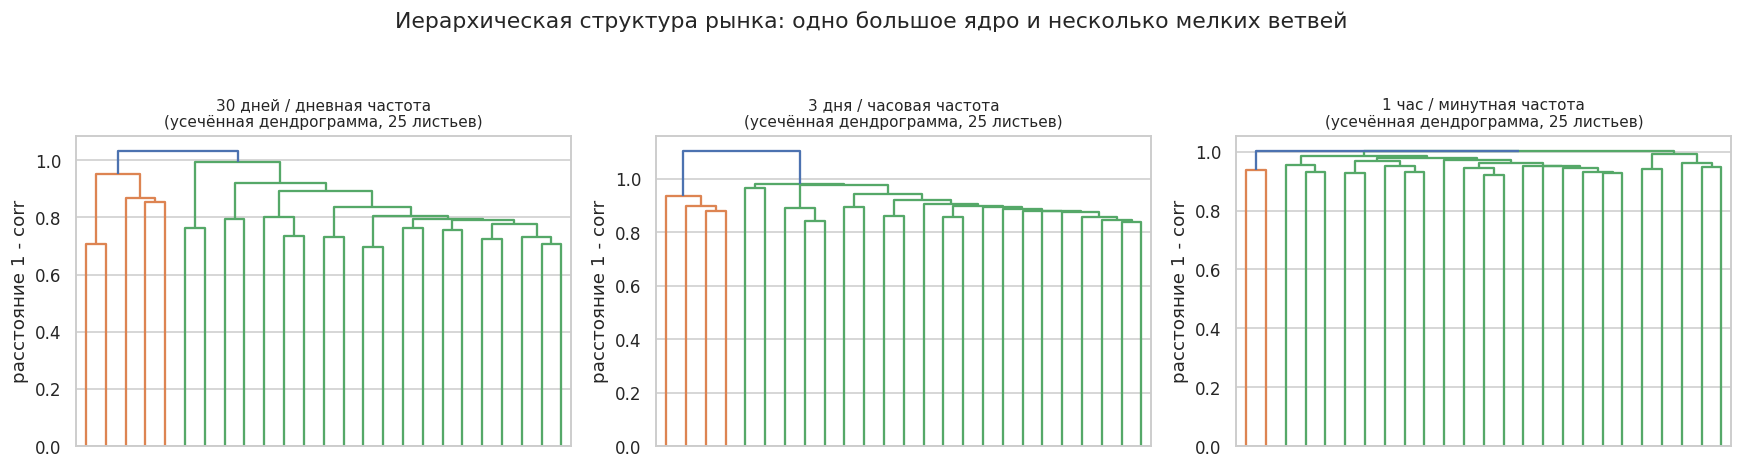

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, key in zip(axes, HORIZONS):
    dendrogram(linkages[key], truncate_mode="lastp", p=25, ax=ax,
               color_threshold=linkages[key][-best_k_hier[key] + 1, 2],
               no_labels=True)
    ax.set_title(f'{HORIZONS[key]["title"]}\n(усечённая дендрограмма, 25 листьев)', fontsize=10)
    ax.set_ylabel("расстояние 1 - corr")
fig.suptitle("Иерархическая структура рынка: одно большое ядро и несколько мелких ветвей", y=1.06)
plt.tight_layout(); plt.show()

30 дней / дневная частота    eps=0.477  кластеров=1  шум=20  кластер BTC=0  вне BTC: 20
   чувствительность: q=0.8: eps=0.376, кластеров=1, шум=51 | q=0.85: eps=0.414, кластеров=1, шум=40 | q=0.9: eps=0.477, кластеров=1, шум=20 | q=0.95: eps=0.575, кластеров=1, шум=9
3 дня / часовая частота      eps=0.648  кластеров=1  шум=20  кластер BTC=0  вне BTC: 20
   чувствительность: q=0.8: eps=0.564, кластеров=1, шум=52 | q=0.85: eps=0.609, кластеров=1, шум=29 | q=0.9: eps=0.648, кластеров=1, шум=20 | q=0.95: eps=0.712, кластеров=1, шум=7
1 час / минутная частота     eps=0.698  кластеров=1  шум=4  кластер BTC=0  вне BTC: 4
   чувствительность: q=0.8: eps=0.671, кластеров=1, шум=20 | q=0.85: eps=0.685, кластеров=1, шум=10 | q=0.9: eps=0.698, кластеров=1, шум=4 | q=0.95: eps=0.712, кластеров=1, шум=4


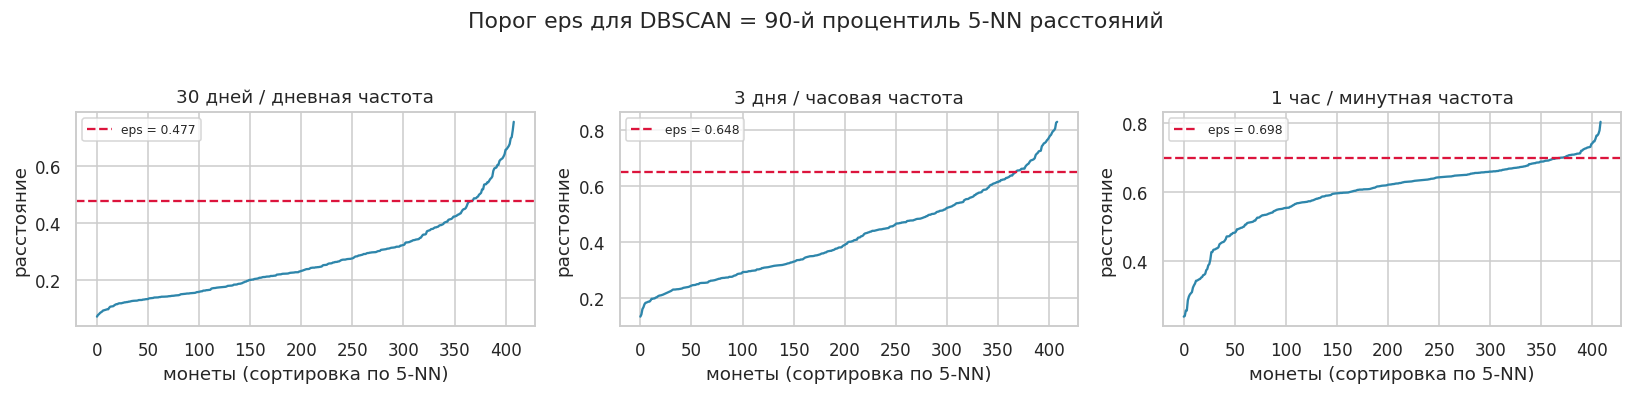

In [19]:
# --- 4.3 DBSCAN на корреляционном расстоянии ---
MIN_SAMPLES = 5
EPS_QUANTILE = 0.90   # допускаем не более ~10 % монет в статусе «шум»

fig, axes = plt.subplots(1, 3, figsize=(15, 3.4))
for ax, (key, f) in zip(axes, feat.items()):
    D = Dcorr[key]
    kdist = np.sort(
        NearestNeighbors(n_neighbors=MIN_SAMPLES, metric="precomputed").fit(D)
        .kneighbors(D)[0][:, -1]
    )
    # чувствительность к порогу: сколько кластеров и шума даёт DBSCAN при разных eps
    sens = []
    for q in (0.80, 0.85, 0.90, 0.95):
        e = float(np.quantile(kdist, q))
        l = DBSCAN(eps=e, min_samples=MIN_SAMPLES, metric="precomputed").fit(D).labels_
        sens.append(f"q={q}: eps={e:.3f}, кластеров={len(set(l[l != -1]))}, шум={(l == -1).sum()}")

    eps = float(np.quantile(kdist, EPS_QUANTILE))
    db = DBSCAN(eps=eps, min_samples=MIN_SAMPLES, metric="precomputed").fit(D)
    lab = pd.Series(db.labels_, index=f["coins"], name="cluster")

    core = (lab != -1).values
    sil = (silhouette_score(D[np.ix_(core, core)], lab.values[core], metric="precomputed")
           if core.sum() > MIN_SAMPLES and pd.Series(lab.values[core]).nunique() > 1 else np.nan)
    out = register(key, "DBSCAN (1-corr)", lab, int(pd.Series(lab.values[core]).nunique()), sil)

    ax.plot(kdist, color="#2E86AB")
    ax.axhline(eps, color="crimson", ls="--", label=f"eps = {eps:.3f}")
    ax.set_title(HORIZONS[key]["title"]); ax.set_xlabel(f"монеты (сортировка по {MIN_SAMPLES}-NN)")
    ax.set_ylabel("расстояние"); ax.legend(fontsize=8)
    print(f'{HORIZONS[key]["title"]:<28} eps={eps:.3f}  '
          f'кластеров={pd.Series(lab.values[core]).nunique()}  '
          f'шум={int((lab == -1).sum())}  кластер BTC={lab[REF]}  вне BTC: {len(out)}')
    print("   чувствительность: " + " | ".join(sens))
fig.suptitle(f"Порог eps для DBSCAN = {int(EPS_QUANTILE * 100)}-й процентиль "
             f"{MIN_SAMPLES}-NN расстояний", y=1.05)
plt.tight_layout(); plt.show()

DBSCAN на этих данных **не находит нескольких плотных групп**: при любом разумном `eps`
получается ровно один кластер плюс шум. Это само по себе результат — рынок действительно
устроен как единое ядро с периферией, — но означает, что здесь DBSCAN работает не как
кластеризатор, а как **детектор выбросов с настраиваемым порогом**: число «нестандартных»
монет у него напрямую задаётся выбором `eps` (см. строку чувствительности выше).
Поэтому его голос ниже используется наравне с остальными, но с поправкой на то,
что он отражает выбранный порог, а не самостоятельно обнаруженную структуру.

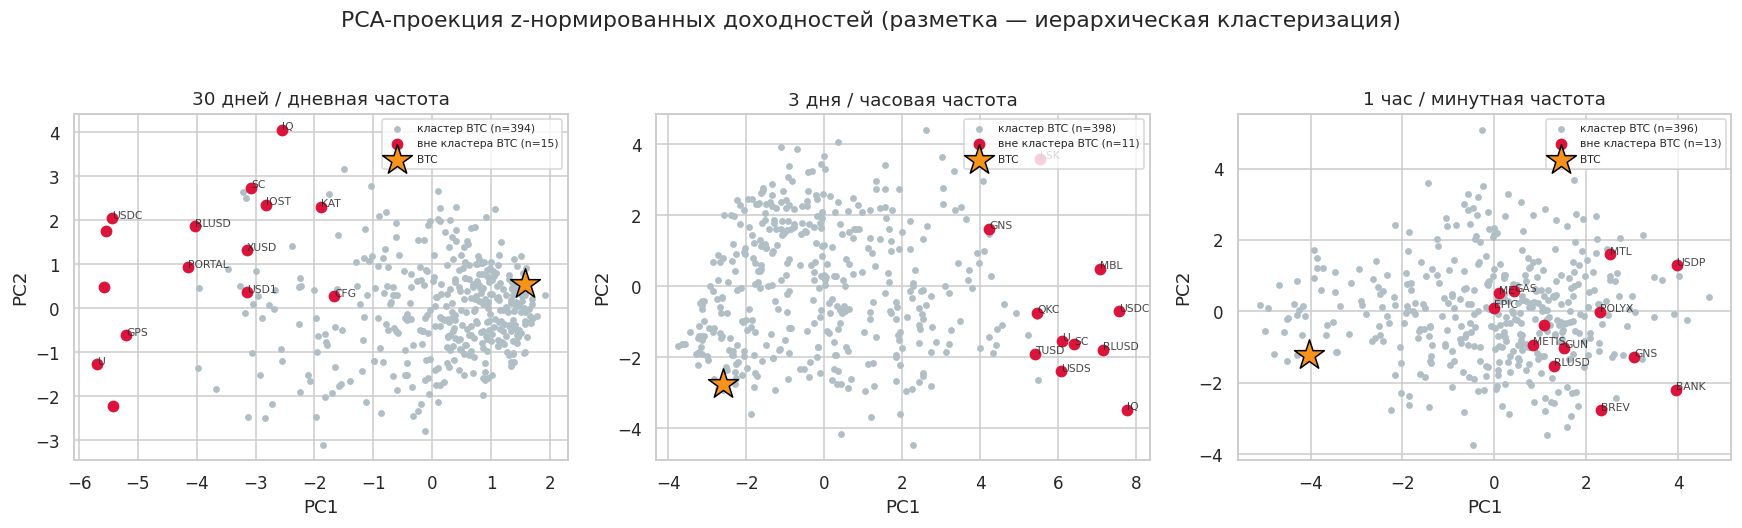

In [20]:
# Визуализация: PCA-проекция облака доходностей, BTC помечен звездой
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for ax, (key, f) in zip(axes, feat.items()):
    coords = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(f["X"])
    lab = results[(key, "Иерархическая (1-corr)")]["labels"]
    btc_lab = lab[REF]
    is_btc_cluster = (lab == btc_lab).values

    ax.scatter(coords[is_btc_cluster, 0], coords[is_btc_cluster, 1], s=12,
               c="#B0BEC5", label=f"кластер BTC (n={is_btc_cluster.sum()})")
    ax.scatter(coords[~is_btc_cluster, 0], coords[~is_btc_cluster, 1], s=45,
               c="crimson", label=f"вне кластера BTC (n={(~is_btc_cluster).sum()})")
    i_btc = int(np.where(f["coins"] == REF)[0][0])
    ax.scatter(*coords[i_btc], marker="*", s=420, c="#F7931A",
               edgecolor="black", zorder=5, label="BTC")
    for i in np.where(~is_btc_cluster)[0][:12]:
        ax.annotate(f["coins"][i], coords[i], fontsize=7, alpha=0.85)
    ax.set_title(HORIZONS[key]["title"]); ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    ax.legend(fontsize=7, loc="best")
fig.suptitle("PCA-проекция z-нормированных доходностей (разметка — иерархическая кластеризация)", y=1.04)
plt.tight_layout(); plt.show()

---
## 5. Кластеризация на основе DTW

**Зачем DTW.** Евклидова метрика и корреляция сравнивают ряды «точка в точку»: если альткоин
повторяет движение биткоина, но с задержкой в несколько баров (что на крипторынке обычная
история — ликвидность перетекает от BTC к альтам не мгновенно), корреляция это движение
недооценит и монета ошибочно окажется «нестандартной».
**Dynamic Time Warping** ищет оптимальное нелинейное выравнивание временных осей и
измеряет расстояние между *формами траекторий*, поэтому сдвиг во времени его не смущает.

**Что подаём на вход.** Для DTW важна траектория, а не приращения, поэтому используем
z-нормированный ряд лог-цен (`z_px`). Нормировка обязательна: без неё DTW снова будет
мерить разницу номиналов.

**Ограничение полосы.** Используем полосу Сакоэ–Чиба радиуса 3: она запрещает выравнивания
с абсурдным сдвигом (для 31-точечного ряда сдвиг в 10 баров — уже не «задержка реакции»,
а другой ряд) и заодно ускоряет расчёт.

Два метода:
1. `TimeSeriesKMeans(metric="dtw")` из `tslearn` — канонический DTW-k-means с DBA-центроидами.
2. Агломеративная кластеризация на **предпосчитанной** матрице попарных DTW-расстояний
   (`cdist_dtw`) — она же переиспользуется для silhouette и для рейтинга «DTW-расстояние до BTC».

In [21]:
from tslearn.clustering import TimeSeriesKMeans
from tslearn.metrics import cdist_dtw

SAKOE_CHIBA_RADIUS = 3
DTW_PARAMS = {"global_constraint": "sakoe_chiba", "sakoe_chiba_radius": SAKOE_CHIBA_RADIUS}


def dtw_matrix(key: str, P: np.ndarray) -> np.ndarray:
    """Матрица попарных DTW-расстояний с кэшированием на диск."""
    cache = DATA_DIR / f"dtw_{key}.npy"
    if cache.exists():
        D = np.load(cache)
        if D.shape[0] == P.shape[0]:
            print(f"[{key}] DTW-матрица из кэша {D.shape}")
            return D
    t0 = time.time()
    D = cdist_dtw(P, n_jobs=-1, **DTW_PARAMS)
    D = (D + D.T) / 2.0
    np.fill_diagonal(D, 0.0)
    np.save(cache, D)
    print(f"[{key}] DTW-матрица {D.shape} посчитана за {time.time() - t0:.0f} c")
    return D


Ddtw = {key: dtw_matrix(key, f["P"]) for key, f in feat.items()}

[30d_daily] DTW-матрица из кэша (409, 409)
[3d_hourly] DTW-матрица из кэша (409, 409)
[1h_minutely] DTW-матрица из кэша (409, 409)


In [22]:
# --- 5.1 Агломеративная кластеризация на матрице DTW-расстояний ---
best_k_dtw = {}
for key, f in feat.items():
    D = Ddtw[key]
    scores = {}
    for k in range(2, 11):
        lab = AgglomerativeClustering(n_clusters=k, metric="precomputed",
                                      linkage="average").fit_predict(D)
        if len(np.unique(lab)) > 1:
            scores[k] = silhouette_score(D, lab, metric="precomputed")
    best_k_dtw[key] = max(scores, key=scores.get)
    lab = pd.Series(
        AgglomerativeClustering(n_clusters=best_k_dtw[key], metric="precomputed",
                                linkage="average").fit_predict(D),
        index=f["coins"], name="cluster",
    )
    out = register(key, "Агломеративная (DTW)", lab, best_k_dtw[key],
                   float(scores[best_k_dtw[key]]))
    print(f'{HORIZONS[key]["title"]:<28} k={best_k_dtw[key]}  sil={scores[best_k_dtw[key]]:.3f}  '
          f'размеры={lab.value_counts().sort_index().tolist()}  вне кластера BTC: {len(out)}')

30 дней / дневная частота    k=2  sil=0.394  размеры=[401, 8]  вне кластера BTC: 8
3 дня / часовая частота      k=2  sil=0.305  размеры=[259, 150]  вне кластера BTC: 259
1 час / минутная частота     k=2  sil=0.260  размеры=[180, 229]  вне кластера BTC: 229


In [23]:
# --- 5.2 TimeSeriesKMeans с метрикой DTW ---
ts_models = {}
for key, f in feat.items():
    k = best_k_dtw[key]
    t0 = time.time()
    model = TimeSeriesKMeans(
        n_clusters=k, metric="dtw", metric_params=DTW_PARAMS,
        max_iter=10, n_init=2, random_state=RANDOM_STATE, n_jobs=-1,
    ).fit(f["P"])
    ts_models[key] = model
    lab = pd.Series(model.labels_, index=f["coins"], name="cluster")
    sil = silhouette_score(Ddtw[key], model.labels_, metric="precomputed") \
        if lab.nunique() > 1 else np.nan
    out = register(key, "TimeSeriesKMeans (DTW)", lab, k, float(sil))
    print(f'{HORIZONS[key]["title"]:<28} k={k}  sil={sil:.3f}  '
          f'размеры={lab.value_counts().sort_index().tolist()}  '
          f'вне кластера BTC: {len(out)}  ({time.time() - t0:.0f} c)')

30 дней / дневная частота    k=2  sil=0.389  размеры=[119, 290]  вне кластера BTC: 119  (19 c)


3 дня / часовая частота      k=2  sil=0.324  размеры=[212, 197]  вне кластера BTC: 212  (20 c)


1 час / минутная частота     k=2  sil=0.287  размеры=[200, 209]  вне кластера BTC: 209  (6 c)


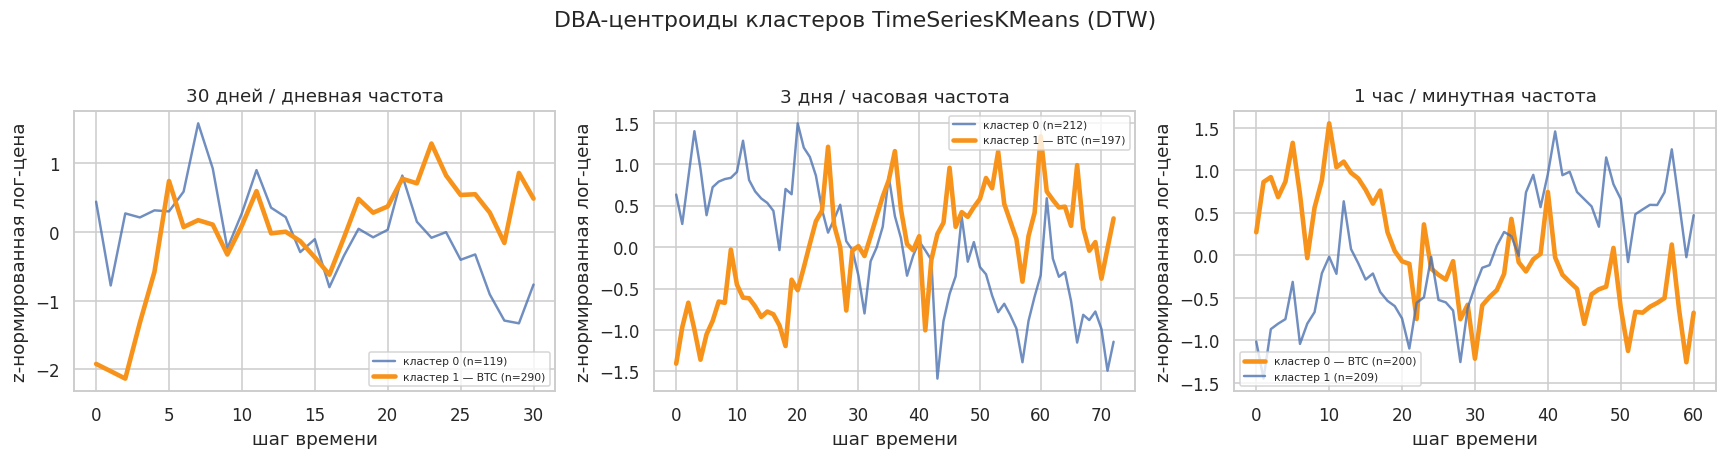

In [24]:
# Центроиды DTW-кластеров: как выглядит «типичная форма» каждой группы
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (key, f) in zip(axes, feat.items()):
    model, lab = ts_models[key], pd.Series(ts_models[key].labels_, index=f["coins"])
    btc_lab = lab[REF]
    for c, centroid in enumerate(model.cluster_centers_):
        is_btc = c == btc_lab
        ax.plot(centroid.ravel(), lw=3 if is_btc else 1.6,
                color="#F7931A" if is_btc else None,
                alpha=1.0 if is_btc else 0.8,
                label=f'кластер {c}{" — BTC" if is_btc else ""} (n={(lab == c).sum()})')
    ax.set_title(HORIZONS[key]["title"]); ax.set_xlabel("шаг времени")
    ax.set_ylabel("z-нормированная лог-цена"); ax.legend(fontsize=7)
fig.suptitle("DBA-центроиды кластеров TimeSeriesKMeans (DTW)", y=1.04)
plt.tight_layout(); plt.show()

Топ-15 монет, наиболее далёких от BTC по DTW-расстоянию:


,30 дней / дневная частота,3 дня / часовая частота,1 час / минутная частота
1,USDE (10.7),HOLO (15.9),RIF (13.7)
2,USDC (10.5),FF (15.6),YB (13.4)
3,USDS (10.5),MINA (15.6),ZAMA (13.3)
4,GENIUS (10.3),LITEB (15.6),A (13.3)
5,U (10.2),EDU (15.5),ENSO (13.2)
6,RLUSD (10.2),ENJ (15.3),CHR (13.1)
7,DODO (10.0),XAUT (15.2),TRX (13.0)
8,KGST (9.9),EURI (15.2),ID (13.0)
9,CFG (9.6),PAXG (15.2),LUMIA (12.9)
10,MANTRA (9.5),XNO (15.2),ASR (12.9)


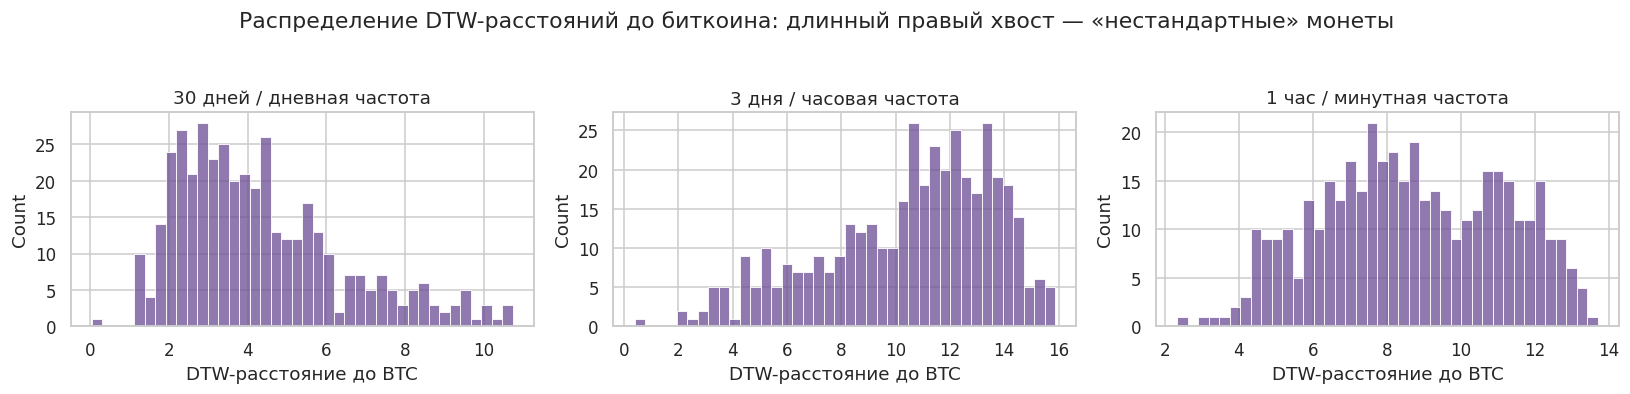

In [25]:
# --- 5.3 Прямой рейтинг: DTW-расстояние каждой монеты до BTC ---
dtw_to_btc = pd.DataFrame(
    {
        key: pd.Series(Ddtw[key][int(np.where(f["coins"] == REF)[0][0])], index=f["coins"])
        for key, f in feat.items()
    }
).drop(index=REF)

top_far = pd.DataFrame(
    {
        HORIZONS[key]["title"]: [
            f"{coin}  ({dist:.1f})" for coin, dist in dtw_to_btc[key].nlargest(15).items()
        ]
        for key in HORIZONS
    }
)
top_far.index = np.arange(1, 16)
print("Топ-15 монет, наиболее далёких от BTC по DTW-расстоянию:")
display(top_far)

fig, axes = plt.subplots(1, 3, figsize=(15, 3.4), sharey=False)
for ax, key in zip(axes, HORIZONS):
    sns.histplot(dtw_to_btc[key], bins=40, ax=ax, color="#6A4C93", edgecolor="white")
    ax.set_title(HORIZONS[key]["title"]); ax.set_xlabel("DTW-расстояние до BTC")
fig.suptitle("Распределение DTW-расстояний до биткоина: длинный правый хвост — «нестандартные» монеты", y=1.05)
plt.tight_layout(); plt.show()

---
## 6. Сводные результаты: 3 горизонта × 5 методов

In [26]:
METHODS = ["KMeans (доходности)", "Иерархическая (1-corr)", "DBSCAN (1-corr)",
           "Агломеративная (DTW)", "TimeSeriesKMeans (DTW)"]


def _row(key, method):
    rec = results[(key, method)]
    n = len(rec["labels"])
    share = 100.0 * rec["btc_cluster_size"] / n
    return {
        "горизонт": HORIZONS[key]["title"],
        "метод": method,
        "семейство": "DTW" if "DTW" in method else "классика",
        "k": rec["k"],
        "silhouette": round(rec["silhouette"], 3) if pd.notna(rec["silhouette"]) else np.nan,
        "монет всего": n,
        "в кластере BTC": rec["btc_cluster_size"],
        "рынка в кластере BTC, %": round(share, 1),
        "вне кластера BTC": rec["n_outside"],
        "доля вне, %": round(100.0 - share, 1),
    }


summary = pd.DataFrame([_row(key, m) for key in HORIZONS for m in METHODS])
summary

,горизонт,метод,семейство,k,silhouette,монет всего,в кластере BTC,"рынка в кластере BTC, %",вне кластера BTC,"доля вне, %"
0,30 дней / дневная частота,KMeans (доходности),классика,2,0.199,409,319,78.0,90,22.0
1,30 дней / дневная частота,Иерархическая (1-corr),классика,2,0.434,409,394,96.3,15,3.7
2,30 дней / дневная частота,DBSCAN (1-corr),классика,1,NaN,409,389,95.1,20,4.9
3,30 дней / дневная частота,Агломеративная (DTW),DTW,2,0.394,409,401,98.0,8,2.0
4,30 дней / дневная частота,TimeSeriesKMeans (DTW),DTW,2,0.389,409,290,70.9,119,29.1
5,3 дня / часовая частота,KMeans (доходности),классика,2,0.119,409,274,67.0,135,33.0
6,3 дня / часовая частота,Иерархическая (1-corr),классика,2,0.353,409,398,97.3,11,2.7
7,3 дня / часовая частота,DBSCAN (1-corr),классика,1,NaN,409,389,95.1,20,4.9
8,3 дня / часовая частота,Агломеративная (DTW),DTW,2,0.305,409,150,36.7,259,63.3
9,3 дня / часовая частота,TimeSeriesKMeans (DTW),DTW,2,0.324,409,197,48.2,212,51.8


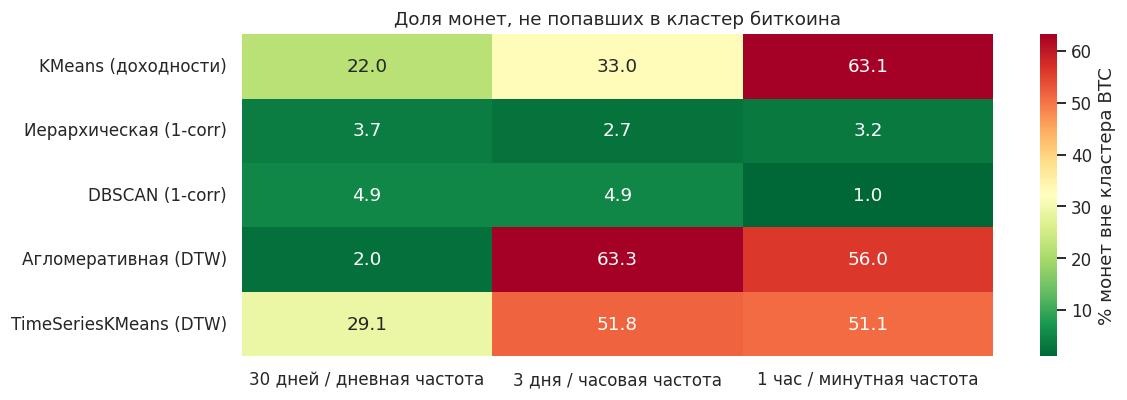

In [27]:
fig, ax = plt.subplots(figsize=(11, 3.8))
pivot = summary.pivot(index="метод", columns="горизонт", values="доля вне, %").loc[METHODS]
pivot = pivot[[HORIZONS[k]["title"] for k in HORIZONS]]
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdYlGn_r", ax=ax,
            cbar_kws={"label": "% монет вне кластера BTC"})
ax.set_title("Доля монет, не попавших в кластер биткоина")
ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout(); plt.show()

### 6.1. Какие методы вообще имеют право голоса

Таблица выше вскрывает проблему: часть ячеек показывает 50–63 % монет «вне кластера BTC».
Разбиение, в котором биткоин оказался в меньшинстве, **не отвечает на поставленный вопрос**:
условие задачи исходит из того, что большинство альткоинов повторяет динамику биткоина,
и «нестандартные» — это узкая периферия. Если метод разрезал рынок примерно пополам,
он не выделил периферию, а просто разделил однородное облако — и его список «вне кластера BTC»
не несёт информации о конкретных монетах.

Формализуем это как **правило допустимости**:

> метод допускается к голосованию на данном горизонте, если кластер, содержащий BTC,
> объединяет **больше половины** рассматриваемых монет.

Это явное модельное допущение (мы принимаем постановку задачи как данность), и у него есть
цена: если бы биткоин действительно оказался в меньшинстве рынка, правило бы это скрыло.
Зато оно автоматически отсекает вырожденные пополам-разбиения, не подгоняя ответ вручную.

In [28]:
ADMISSIBLE = {
    key: [m for m in METHODS
          if results[(key, m)]["btc_cluster_size"] / len(results[(key, m)]["labels"]) > 0.5]
    for key in HORIZONS
}

summary["метод допустим"] = [
    m in ADMISSIBLE[key] for key in HORIZONS for m in METHODS
]

for key in HORIZONS:
    rejected = [m for m in METHODS if m not in ADMISSIBLE[key]]
    print(f'{HORIZONS[key]["title"]:<28} допущено {len(ADMISSIBLE[key])}/5: '
          f'{", ".join(ADMISSIBLE[key])}')
    if rejected:
        print(f'{"":<28} отклонено: {", ".join(rejected)}')

display(summary[["горизонт", "метод", "рынка в кластере BTC, %", "метод допустим"]])

30 дней / дневная частота    допущено 5/5: KMeans (доходности), Иерархическая (1-corr), DBSCAN (1-corr), Агломеративная (DTW), TimeSeriesKMeans (DTW)
3 дня / часовая частота      допущено 3/5: KMeans (доходности), Иерархическая (1-corr), DBSCAN (1-corr)
                             отклонено: Агломеративная (DTW), TimeSeriesKMeans (DTW)
1 час / минутная частота     допущено 2/5: Иерархическая (1-corr), DBSCAN (1-corr)
                             отклонено: KMeans (доходности), Агломеративная (DTW), TimeSeriesKMeans (DTW)


,горизонт,метод,"рынка в кластере BTC, %",метод допустим
0,30 дней / дневная частота,KMeans (доходности),78.0,True
1,30 дней / дневная частота,Иерархическая (1-corr),96.3,True
2,30 дней / дневная частота,DBSCAN (1-corr),95.1,True
3,30 дней / дневная частота,Агломеративная (DTW),98.0,True
4,30 дней / дневная частота,TimeSeriesKMeans (DTW),70.9,True
5,3 дня / часовая частота,KMeans (доходности),67.0,True
6,3 дня / часовая частота,Иерархическая (1-corr),97.3,True
7,3 дня / часовая частота,DBSCAN (1-corr),95.1,True
8,3 дня / часовая частота,Агломеративная (DTW),36.7,False
9,3 дня / часовая частота,TimeSeriesKMeans (DTW),48.2,False


### 6.2. Консенсус методов

Считаем два варианта голосования, чтобы видеть, что даёт фильтр допустимости:

* **наивный** — доля из всех 5 методов, вынесших монету за пределы кластера BTC;
* **устойчивый** — доля только среди допустимых методов данного горизонта.

Монету считаем обособленной на горизонте, если за это высказалась **не менее половины**
допустимых методов. Универсум — монеты, присутствующие на всех трёх горизонтах
(иначе знаменатели у разных монет были бы разными и рейтинг стал бы несопоставимым).

In [29]:
horizon_cols = [HORIZONS[k]["title"] for k in HORIZONS]
VOTE_THRESHOLD = 0.5

coin_sets = [set(feat[k]["coins"]) for k in HORIZONS]
common_coins = sorted(set.intersection(*coin_sets) - {REF})
union_coins = sorted(set().union(*coin_sets) - {REF})
print(f"Монет на всех трёх горизонтах: {len(common_coins)} "
      f"(в объединении {len(union_coins)}, исключено {len(union_coins) - len(common_coins)})")

votes = pd.DataFrame(index=common_coins)     # устойчивое голосование, доля допустимых методов
naive = pd.DataFrame(index=common_coins)     # наивное голосование, число методов из 5

for key in HORIZONS:
    outs = {m: set(results[(key, m)]["outside"]) for m in METHODS}
    adm = ADMISSIBLE[key]
    votes[HORIZONS[key]["title"]] = [
        round(sum(c in outs[m] for m in adm) / len(adm), 2) for c in common_coins
    ]
    naive[HORIZONS[key]["title"]] = [sum(c in outs[m] for m in METHODS) for c in common_coins]

votes["горизонтов с отрывом"] = (votes[horizon_cols] >= VOTE_THRESHOLD).sum(axis=1)
votes["наивных голосов (из 15)"] = naive.sum(axis=1)
votes["ср. DTW-расстояние до BTC"] = dtw_to_btc.mean(axis=1).reindex(votes.index).round(2)
votes = votes.sort_values(["горизонтов с отрывом"] + horizon_cols, ascending=False)

naive_tiers = (naive >= 3).sum(axis=1)
print(f'Монет, обособленных на всех трёх горизонтах: '
      f'{int((naive_tiers == 3).sum())} по наивному голосованию, '
      f'{int((votes["горизонтов с отрывом"] == 3).sum())} по устойчивому')
print(f'Монет, обособленных хотя бы на одном горизонте: '
      f'{int((naive_tiers >= 1).sum())} против {int((votes["горизонтов с отрывом"] >= 1).sum())}')

print("\nТоп-25 монет по «непохожести на биткоин» (устойчивое голосование):")
votes.head(25)

Монет на всех трёх горизонтах: 408 (в объединении 408, исключено 0)
Монет, обособленных на всех трёх горизонтах: 4 по наивному голосованию, 2 по устойчивому
Монет, обособленных хотя бы на одном горизонте: 168 против 44

Топ-25 монет по «непохожести на биткоин» (устойчивое голосование):


,30 дней / дневная частота,3 дня / часовая частота,1 час / минутная частота,горизонтов с отрывом,наивных голосов (из 15),ср. DTW-расстояние до BTC
RLUSD,1.0,1.00,0.5,3,10,10.41
USDP,0.8,0.67,0.5,3,8,8.59
U,1.0,1.00,0.0,2,9,7.55
USDC,1.0,1.00,0.0,2,11,10.14
USDS,1.0,1.00,0.0,2,9,10.48
USD1,1.0,0.67,0.0,2,12,10.70
USDE,1.0,0.67,0.0,2,12,10.89
KGST,0.8,0.67,0.0,2,9,8.79
PORTAL,0.6,0.67,0.0,2,6,8.56
SC,0.4,1.00,0.5,2,9,7.13


### 6.3. Итоговая классификация

| Уровень | Критерий | Интерпретация |
|---|---|---|
| **A — ядро** | обособлена на всех 3 горизонтах | динамика не связана с BTC ни на каком масштабе |
| **B — устойчивые** | обособлена на 2 горизонтах из 3 | независимость есть, но проявляется не на всех частотах |
| **C — эпизодические** | обособлена на 1 горизонте | скорее локальное событие или шум оценки |

Оговорка по минутному горизонту: там допустимыми оказались всего два метода, поэтому его
голос самый грубый — «не менее половины» означает согласие одного метода из двух.

In [30]:
tier_map = {3: "A — ядро", 2: "B — устойчивые", 1: "C — эпизодические"}
votes["уровень"] = votes["горизонтов с отрывом"].map(tier_map).fillna("— (в кластере BTC)")
votes = votes.join(coin_meta[["CoinName"]], how="left")

show_cols = ["CoinName", "наивных голосов (из 15)", "ср. DTW-расстояние до BTC"] + horizon_cols

print("Распределение монет по уровням устойчивости:")
display(votes["уровень"].value_counts().rename("монет").to_frame())

nonstandard = votes[votes["горизонтов с отрывом"] == 3].copy()
print(f"\nУровень A: {len(nonstandard)} из {len(common_coins)} монет")
display(nonstandard[show_cols])

tier_b = votes[votes["горизонтов с отрывом"] == 2].copy()
print(f"Уровень B: {len(tier_b)} монет")
display(tier_b[show_cols])

export = votes[votes["горизонтов с отрывом"] >= 1][
    ["CoinName", "уровень", "наивных голосов (из 15)", "ср. DTW-расстояние до BTC"] + horizon_cols
]
export.to_csv(DATA_DIR / "nonstandard_cryptocurrencies.csv")
print("\nСохранено", len(export), "строк в", DATA_DIR / "nonstandard_cryptocurrencies.csv")

Распределение монет по уровням устойчивости:


,монет
уровень,
— (в кластере BTC),364
C — эпизодические,33
B — устойчивые,9
A — ядро,2



Уровень A: 2 из 408 монет


,CoinName,наивных голосов (из 15),ср. DTW-расстояние до BTC,30 дней / дневная частота,3 дня / часовая частота,1 час / минутная частота
RLUSD,Ripple USD,10,10.41,1.0,1.00,0.5
USDP,Pax Dollar,8,8.59,0.8,0.67,0.5


Уровень B: 9 монет


,CoinName,наивных голосов (из 15),ср. DTW-расстояние до BTC,30 дней / дневная частота,3 дня / часовая частота,1 час / минутная частота
U,United Stables,9,7.55,1.0,1.00,0.0
USDC,USD Coin,11,10.14,1.0,1.00,0.0
USDS,Sky Dollar,9,10.48,1.0,1.00,0.0
USD1,World Liberty Financial USD,12,10.70,1.0,0.67,0.0
USDE,Ethena USDe,12,10.89,1.0,0.67,0.0
KGST,KGST,9,8.79,0.8,0.67,0.0
PORTAL,Portal,6,8.56,0.6,0.67,0.0
SC,Siacoin,9,7.13,0.4,1.00,0.5
GNS,Gains Network,8,10.02,0.2,0.67,0.5



Сохранено 44 строк в /home/ubuntu/projects/ml/machine_learning_expert/hw_02_2/data/nonstandard_cryptocurrencies.csv


### 6.4. Чем объясняется обособленность: диагностика найденных монет

Попадание в периферию само по себе не говорит, *почему* монета не ходит за биткоином.
Есть два принципиально разных механизма:

* **цена привязана или фактически заморожена** — стейблкоины и неликвидные токены,
  у которых дневная волатильность близка к нулю: «беты» к BTC нет по построению;
* **собственная волатильная динамика** — монета живёт своей жизнью на фоне рыночного
  движения, и это как раз содержательный ответ на задачу.

Различить их легко по дневной сигме и обороту.

In [31]:
diag_coins = list(nonstandard.index) + list(tier_b.index)
px_d, lr_d = feat["30d_daily"]["px"], feat["30d_daily"]["logret"]
vol24 = universe.set_index("base")["quote_volume_24h"]

diag = pd.DataFrame({
    "CoinName": coin_meta["CoinName"].reindex(diag_coins),
    "уровень": votes["уровень"].reindex(diag_coins),
    "оборот 24ч, $": vol24.reindex(diag_coins).round(0),
    "изм. за 30 д, %": (100 * (px_d[diag_coins].iloc[-1] / px_d[diag_coins].iloc[0] - 1)).round(1),
    "дневная сигма, %": (100 * lr_d[diag_coins].std()).round(2),
    "corr с BTC (дн.)": lr_d[diag_coins].corrwith(lr_d[REF]).round(2),
})
FLAT_SIGMA = 0.5   # %/день — порог «цена практически не двигается»
diag["механизм"] = np.where(diag["дневная сигма, %"] < FLAT_SIGMA,
                            "привязка / замороженная цена",
                            "собственная волатильная динамика")

btc_row = pd.DataFrame({
    "CoinName": ["Bitcoin (эталон)"], "уровень": ["—"],
    "оборот 24ч, $": [round(vol24[REF])],
    "изм. за 30 д, %": [round(100 * (px_d[REF].iloc[-1] / px_d[REF].iloc[0] - 1), 1)],
    "дневная сигма, %": [round(100 * lr_d[REF].std(), 2)],
    "corr с BTC (дн.)": [1.0], "механизм": ["—"],
}, index=[REF])

display(pd.concat([diag.sort_values(["уровень", "дневная сигма, %"]), btc_row]))
print(diag["механизм"].value_counts().to_string())

,CoinName,уровень,"оборот 24ч, $","изм. за 30 д, %","дневная сигма, %",corr с BTC (дн.),механизм
RLUSD,Ripple USD,A — ядро,5.697051e+07,-0.1,0.02,-0.16,привязка / замороженная цена
USDP,Pax Dollar,A — ядро,8.694600e+04,-0.3,0.12,-0.30,привязка / замороженная цена
U,United Stables,B — устойчивые,4.927551e+07,-0.0,0.02,-0.37,привязка / замороженная цена
USDC,USD Coin,B — устойчивые,2.896987e+09,-0.1,0.02,-0.49,привязка / замороженная цена
USDS,Sky Dollar,B — устойчивые,1.942200e+05,-0.1,0.02,-0.41,привязка / замороженная цена
USD1,World Liberty Financial USD,B — устойчивые,1.689519e+08,-0.0,0.02,-0.18,привязка / замороженная цена
USDE,Ethena USDe,B — устойчивые,3.760730e+05,-0.1,0.02,-0.36,привязка / замороженная цена
KGST,KGST,B — устойчивые,4.130500e+04,-0.3,0.18,-0.10,привязка / замороженная цена
GNS,Gains Network,B — устойчивые,1.481360e+05,-16.2,2.66,0.57,собственная волатильная динамика
PORTAL,Portal,B — устойчивые,8.501830e+05,12.4,9.55,-0.12,собственная волатильная динамика


механизм
привязка / замороженная цена        8
собственная волатильная динамика    3


In [32]:
# Пересечения списков «вне кластера BTC» по горизонтам (иерархический метод как опорный)
sets_h = {HORIZONS[k]["title"]: set(results[(k, "Иерархическая (1-corr)")]["outside"])
          for k in HORIZONS}
sets_d = {HORIZONS[k]["title"]: set(results[(k, "Агломеративная (DTW)")]["outside"])
          for k in HORIZONS}

def show_set(s, limit=25):
    items = sorted(s)
    return ", ".join(items[:limit]) + (f" ... (+{len(items) - limit})" if len(items) > limit else "")


print("Классика (иерархическая, 1-corr):")
for name, st in sets_h.items():
    print(f"  {name:<28} {len(st):>3}: {show_set(st)}")
print("  пересечение трёх горизонтов:", sorted(set.intersection(*sets_h.values())))

print("\nDTW (агломеративная):")
for name, st in sets_d.items():
    print(f"  {name:<28} {len(st):>3}: {show_set(st)}")
print("  пересечение трёх горизонтов:", sorted(set.intersection(*sets_d.values())))

common = set.intersection(*sets_h.values()) & set.intersection(*sets_d.values())
print("\nОбщее ядро (классика ∩ DTW ∩ все три горизонта):", sorted(common))

Классика (иерархическая, 1-corr):
  30 дней / дневная частота     15: CFG, GPS, IOST, IQ, KAT, PORTAL, RLUSD, SC, U, USD1, USDC, USDE, USDP, USDS, XUSD
  3 дня / часовая частота       11: GNS, IQ, LSK, MBL, QKC, RLUSD, SC, TUSD, U, USDC, USDS
  1 час / минутная частота      13: BANK, BREV, EPIC, GAS, GNS, GUN, ME, METIS, MTL, POLYX, RLUSD, TURTLE, USDP
  пересечение трёх горизонтов: ['RLUSD']

DTW (агломеративная):
  30 дней / дневная частота      8: KGST, RLUSD, U, USD1, USDC, USDE, USDS, XUSD
  3 дня / часовая частота      259: 1000SATS, ACE, ACM, ACT, ADA, AERO, AEVO, AI, AIXBT, ALICE, ALLO, ALPINE, AMP, APE, APT, ARB, ASR, AT, ATOM, AVA, AVNT, BANANA, BANANAS31, BANK, BAR ... (+234)
  1 час / минутная частота     229: 0G, 1000SATS, 1INCH, 2Z, A, AAVE, ACE, ACH, ACT, AEVO, AGLD, AIXBT, ALGO, ALICE, AMP, API3, APT, AR, ARK, ARKM, ARPA, ASR, ASTER, AT, ATOM ... (+204)
  пересечение трёх горизонтов: ['USD1', 'USDE', 'XUSD']

Общее ядро (классика ∩ DTW ∩ все три горизонта): []


Пустое «общее ядро» здесь не противоречие, а прямое следствие раздела 6.1: списки
агломеративной DTW-кластеризации на часовом и минутном горизонтах получены из вырожденных
разбиений рынка пополам, поэтому пересекать их с корректными списками бессмысленно.
Именно поэтому итоговый ответ строится по голосованию **допустимых** методов, а не по
пересечению всех подряд.

На графиках: RLUSD [A], USDP [A], U [B], USDC [B], USDS [B], USD1 [B], USDE [B], KGST [B]


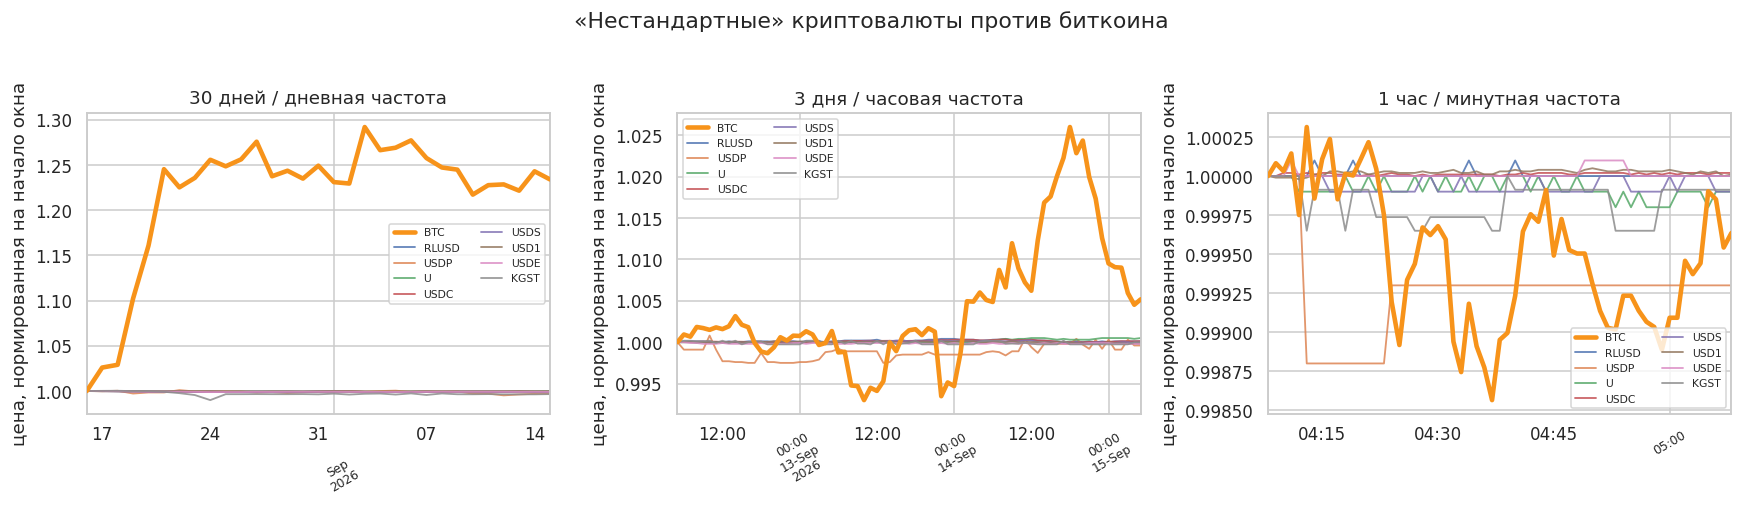

In [33]:
# Как выглядят найденные «нестандартные» монеты рядом с биткоином
# (уровень A целиком, далее добиваем верхом уровня B — до 8 линий на графике)
show = list(nonstandard.index) + list(tier_b.index)
show = show[:8]
print("На графиках:", ", ".join(f"{c} [{votes.loc[c, 'уровень'][0]}]" for c in show))
if show:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
    for ax, (key, f) in zip(axes, feat.items()):
        norm = f["px"] / f["px"].iloc[0]
        norm[REF].plot(ax=ax, color="#F7931A", lw=3, label="BTC", zorder=5)
        for coin in show:
            if coin in norm.columns:
                norm[coin].plot(ax=ax, lw=1.2, alpha=0.85, label=coin)
        ax.set_title(HORIZONS[key]["title"]); ax.set_xlabel("")
        ax.set_ylabel("цена, нормированная на начало окна")
        ax.tick_params(axis="x", rotation=30, labelsize=8)
        ax.legend(fontsize=7, ncol=2)
    fig.suptitle("«Нестандартные» криптовалюты против биткоина", y=1.04)
    plt.tight_layout(); plt.show()

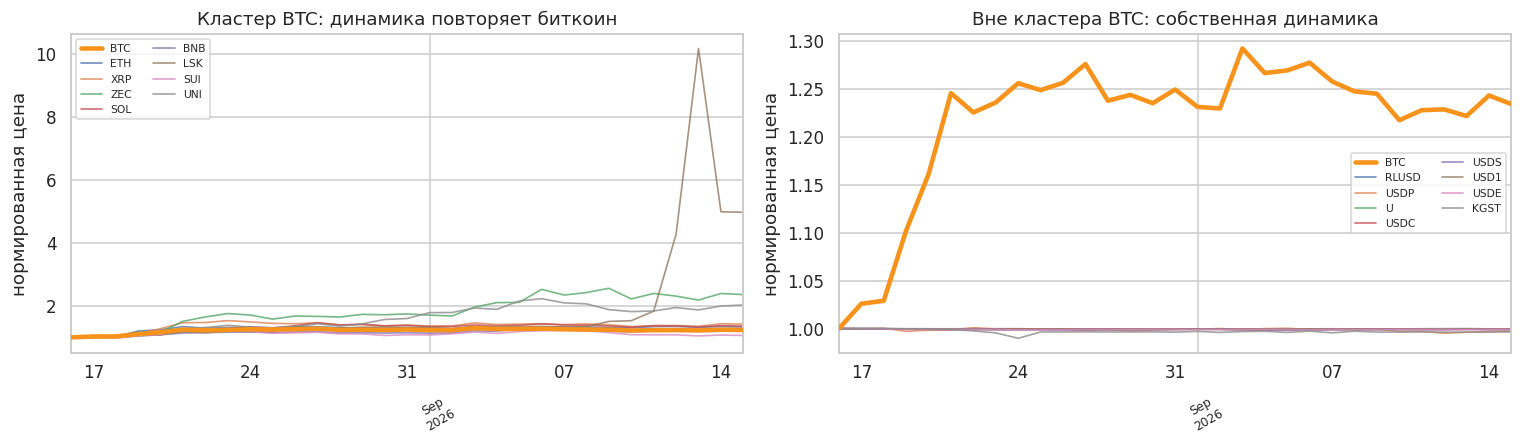

In [34]:
# Контрольный пример: типичные представители кластера BTC ведут себя иначе
btc_cluster = set(results[("30d_daily", "Иерархическая (1-corr)")]["labels"].index) - set(
    results[("30d_daily", "Иерархическая (1-corr)")]["outside"]
)
inside = [c for c in universe.sort_values("quote_volume_24h", ascending=False)["base"]
          if c in btc_cluster and c != REF][:8]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2), sharey=False)
key = "30d_daily"
norm = feat[key]["px"] / feat[key]["px"].iloc[0]
for ax, group, title in [
    (axes[0], inside, "Кластер BTC: динамика повторяет биткоин"),
    (axes[1], show, "Вне кластера BTC: собственная динамика"),
]:
    norm[REF].plot(ax=ax, color="#F7931A", lw=3, label="BTC", zorder=5)
    for coin in group:
        if coin != REF and coin in norm.columns:
            norm[coin].plot(ax=ax, lw=1.1, alpha=0.8, label=coin)
    ax.set_title(title); ax.set_xlabel(""); ax.set_ylabel("нормированная цена")
    ax.tick_params(axis="x", rotation=30, labelsize=8); ax.legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.show()

---
## 7. Выводы

### 7.1. О данных

* `cryptocompare.get_coin_list(format=True)` вернул **20 110** тикеров — существенно больше
  5600 из условия: задание писалось несколько лет назад, с тех пор рынок сильно вырос.
* Но «есть в списке» ≠ «торгуется». После фильтра «ликвидный рынок к доллару с ненулевым
  оборотом за 24 часа» остаётся **576** монет, а после выравнивания на актуальную временную
  сетку BTC и отбрасывания рядов с покрытием < 90 % (делистинги, замершая ликвидность) —
  **409**. То есть содержательный анализ возможен примерно по 2 % тикеров из списка;
  остальные либо мертвы, либо торгуются вне рассмотренной площадки.
* Исторические эндпоинты CryptoCompare после перехода сервиса под CoinDesk требуют API-ключ,
  поэтому котировки загружены из публичного зеркала биржевого API. Код под `cryptocompare`
  написан и включается автоматически при наличии ключа; методика от источника не зависит.

### 7.2. Структура рынка: связь с биткоином убывает с ростом частоты

| Горизонт | Медианная корреляция с BTC | silhouette KMeans (k=2) |
|---|---|---|
| 30 дней, дневная частота | **+0.57** | 0.199 |
| 3 дня, часовая частота | **+0.37** | 0.119 |
| 1 час, минутная частота | **+0.10** | 0.031 |

Это главный содержательный результат: **«кластер биткоина» существует только на низких
частотах**. На дневных данных общий рыночный фактор виден невооружённым глазом, на часовых
он ослабевает, а на минутных доходностях практически исчезает — там доминирует
микроструктурный шум конкретного инструмента. Следовательно, минутный горизонт в принципе
плохо подходит для вопроса «кто не похож на биткоин»: формально кластеризация отработает,
но её выход будет нестабильным. Это подтверждается прямо: у иерархического метода
пересечение списков по трём горизонтам — ровно одна монета (`RLUSD`), а из пяти методов
на минутных данных осмысленный результат дают только два.

Абсолютные значения silhouette невысокие. Облако финансовых доходностей не распадается
на плотные шары: это одно «ядро рынка» с размытой периферией. Для такой геометрии
центроидные методы плохо подходят, а связные и плотностные — хорошо.

### 7.3. Сравнение методов: дело не в «классика против DTW», а в «центроидные против связных»

Доля монет, вынесенных за пределы кластера BTC (жирным — разбиения, где биткоин оказался
в меньшинстве, то есть метод не выделил периферию, а разрезал рынок пополам):

| Метод | 30 д / день | 3 д / час | 1 ч / минута |
|---|---|---|---|
| KMeans (доходности) | 22.0 % | 33.0 % | **63.1 %** |
| Иерархическая, 1−corr | 3.7 % | 2.7 % | 3.2 % |
| DBSCAN, 1−corr | 4.9 % | 4.9 % | 1.0 % |
| Агломеративная (DTW) | 2.0 % | **63.3 %** | **56.0 %** |
| TimeSeriesKMeans (DTW) | 29.1 % | **51.8 %** | **51.1 %** |

* **`KMeans` и `TimeSeriesKMeans` для этой задачи плохо приспособлены.** Оба минимизируют
  внутрикластерную дисперсию и поэтому режут почти однородное облако на куски сопоставимого
  объёма: «вне кластера BTC» у них оказывается от четверти до двух третей рынка. Это
  свойство алгоритма, а не свойство монет.
* **Иерархическая кластеризация (average linkage) даёт ровно ту картину, которую описывает
  условие задачи:** одно плотное ядро из 394–398 монет, где лежит BTC, плюс периферия из
  11–15 монет. Её выход стабилен по горизонтам, а silhouette на дневных данных (0.434) —
  лучший результат во всём эксперименте.
* **`DBSCAN` здесь вырождается в детектор выбросов.** При любом разумном `eps` он находит
  ровно один кластер плюс шум — то есть подтверждает структуру «ядро + периферия», но
  размер периферии у него напрямую задаётся порогом (проверка чувствительности в разделе 4.3:
  на дневном горизонте — от 51 «выброса» при `eps` на уровне 80-го процентиля до 9 при 95-м). Его голос
  содержателен, но это голос за структуру, а не за конкретное число монет.
* **DTW окупается только на дневном горизонте.** Там агломеративная кластеризация на матрице
  DTW-расстояний дала самый «чистый» результат за весь эксперимент — 8 монет из 409
  (silhouette 0.394). Смысл понятен: DTW прощает альткоину задержку реакции на движение BTC,
  поэтому монеты, которые корреляция ошибочно объявляла самостоятельными, возвращаются
  в кластер биткоина.
* **На коротких горизонтах DTW ломается.** На часовых и минутных данных он делит рынок
  примерно пополам, и BTC оказывается в меньшей половине. Причина в природе данных:
  на окне в 3 дня (или в час) форма z-нормированной траектории определяется в основном
  направлением дрейфа, поэтому DTW разбивает монеты на «росли» и «падали». Плюс полоса
  Сакоэ–Чиба радиуса 3 на 61-точечном ряду — это уже 5 % длины окна, то есть допуск на сдвиг
  сопоставим с самим сигналом. Вывод практический: **DTW имеет смысл, когда длина ряда
  заметно больше допустимого сдвига; на коротких высокочастотных окнах он даёт
  бессодержательное разбиение.**
* Поэтому финальный ответ строится не по одному методу и не по слепому голосованию всех
  пяти, а по голосованию **допустимых** методов (раздел 6.1): 5 из 5 на дневном горизонте,
  3 из 5 на часовом, 2 из 5 на минутном. Эффект фильтра хорошо виден: наивное голосование
  помечает «непохожими хотя бы на одном горизонте» 168 монет из 408, голосование допустимых
  методов — 44. Разница почти целиком состоит из монет, которые попали в список только
  потому, что центроидный метод разрезал рынок пополам.

### 7.4. Кто же не похож на биткоин

Из 408 монет, присутствующих на всех трёх горизонтах: **364** уверенно сидят в кластере
биткоина, **33** обособляются эпизодически (уровень C — одно окно из трёх, скорее локальное
событие или шум оценки), **9** устойчиво (уровень B) и **2** — на всех трёх горизонтах.

**Уровень A — ядро ответа:**

| Тикер | Название | Наивных голосов из 15 | Ср. DTW-расстояние до BTC |
|---|---|---|---|
| `RLUSD` | Ripple USD | 10 | 10.41 |
| `USDP` | Pax Dollar | 8 | 8.59 |

Обе монеты — **стейблкоины**. Это ожидаемый результат и одновременно встроенная проверка
корректности пайплайна: у монеты, привязанной к доллару, доходности почти нулевые и
не имеют никакой «беты» к биткоину, поэтому она обязана выпадать из его кластера на любом
масштабе. Если бы стейблкоины оказались внутри кластера BTC, методику следовало бы
считать сломанной.

**Уровень B — 9 монет, обособленные на двух горизонтах из трёх.** Здесь две группы:

1. **Ещё пять инструментов с привязкой к доллару:** `USDC`, `USDE` (Ethena USDe),
   `USD1` (World Liberty Financial USD), `USDS` (Sky Dollar), `U` (United Stables).
   Все они уверенно обособлены на дневном и часовом горизонтах и теряются на минутном —
   ровно там, где корреляционная структура рынка уже неразличима.
2. **Настоящие идиосинкратические альткоины** — `SC`, `GNS` и `PORTAL`. Диагностика
   из раздела 6.4 позволяет говорить о каждом предметно:
   * `SC` (Siacoin) — самый убедительный пример: **+94 % за 30 дней** при дневной сигме
     11.9 % и корреляции с BTC **+0.02**. Монета отработала собственное движение,
     полностью развязанное с рынком;
   * `PORTAL` — сигма 9.6 % в день, корреляция с BTC **−0.12**, то есть тоже своя динамика;
   * `GNS` (Gains Network) обособлен на часовом и минутном горизонтах, но на дневном идёт
     вместе с рынком (корреляция **+0.57**, ровно медиана рынка). Его независимость —
     внутридневная, а не среднесрочная, и это хорошо видно по разнице голосов
     по горизонтам (0.2 / 0.67 / 0.5).

   А вот `KGST` в эту группу **не попадает**, хотя формально он альткоин: его дневная сигма
   — **0.18 %** при обороте всего $41 тыс. Цена фактически заморожена, и обособленность
   от BTC вызвана неликвидностью, а не собственной динамикой. По механизму он ближе
   к первой группе.

Содержательный ответ на задачу — именно `SC`, `PORTAL` и `GNS`: стейблкоины (и примкнувший
к ним по механизму `KGST`) «не похожи на биткоин» тривиально, по построению, а эти три
монеты действительно движутся не по рынку.

Отдельно стоит отметить токены на золото `PAXG` и `XAUT`: они не прошли порог голосования,
но входят в топ-15 по DTW-расстоянию до BTC на часовом горизонте — их динамику определяет
цена золота, а не крипторынок. Это напоминание, что рейтинг по расстоянию и голосование
по кластерам отвечают на немного разные вопросы: первое измеряет непохожесть непрерывно,
второе требует, чтобы монета выделилась в отдельную группу.

**Практический смысл.** Стейблкоины полезны как «тихая гавань» и инструмент
риск-менеджмента, вторая группа — как источник диверсификации внутри крипторынка,
поскольку её доходность не объясняется движением BTC. Но у второй группы декорреляция
часто вызвана не фундаментальной независимостью проекта, а низкой ликвидностью, и при
построении портфеля это нужно проверять отдельно: на большом объёме такая «независимость»
превращается в проскальзывание.

### 7.5. Ограничения и что можно улучшить

* **Правило допустимости — это модельное допущение.** Мы принимаем постановку задачи как
  данность: большинство рынка ходит за биткоином, значит разбиение, где BTC в меньшинстве,
  на вопрос не отвечает. Если бы биткоин действительно оказался в меньшинстве, правило бы
  это скрыло. Оно отсекает вырожденные разбиения автоматически, но не является
  нейтральным критерием качества кластеризации.
* **Минутный горизонт держится на двух методах.** После фильтра там осталось 2 допустимых
  метода из 5, поэтому порог «не менее половины» означает согласие одного метода из двух —
  самый слабый голос в схеме. Честнее было бы либо удлинить окно, либо исключить минутный
  горизонт из итоговой классификации.
* **Окна коротки по построению задачи** (31/73/61 точка). Стандартная ошибка оценки
  корреляции по 30 точкам — около 0.18, поэтому часть монет уровня C на дневном горизонте
  почти наверняка шум. Лечится удлинением окна или бутстрэпом устойчивости кластеров.
* **Вселенная ограничена** парами к доллару одной площадки: монеты, торгующиеся только
  против BTC или на других биржах, в выборку не попали.
* **Использованы только цены закрытия.** Диагностика из раздела 6.4 отделяет «привязку /
  замороженную цену» от «собственной динамики» по дневной сигме и обороту, но это грубый
  признак: добавление спреда, глубины стакана и внутрибаровой волатильности позволило бы
  разделить эти механизмы надёжнее.
* **Естественное развитие:** убрать общий рыночный фактор (первую главную компоненту
  доходностей) и кластеризовать остатки. Тогда нашлись бы монеты с собственной структурой
  со-движения — например, сектора (L2-токены, мем-коины, DeFi), — а не только те,
  что просто не ходят за рынком.
* **Для DTW** стоило бы подбирать радиус полосы Сакоэ–Чиба отдельно под каждый горизонт
  (как долю длины окна), а не брать общую константу: именно фиксированный радиус 3
  частично объясняет деградацию DTW на коротких окнах.

In [35]:
# Итоговая сводка одним взглядом
print("=" * 78)
print("ИТОГИ")
print("=" * 78)
print(f"Монет в списке CryptoCompare              : {len(coin_symbols)}")
print(f"Монет с ликвидным рынком (вселенная)      : {len(universe)}")
print(f"Монет после чистки на всех горизонтах     : {len(common_coins) + 1}")
print()
for key in HORIZONS:
    med = corr_btc[key].median()
    print(f'{HORIZONS[key]["title"]:<28} медианная корр. с BTC = {med:+.3f}')
print()
print(f'Уровень A (обособлены на всех 3 горизонтах): {len(nonstandard)}  ->  '
      f'{", ".join(nonstandard.index) if len(nonstandard) else "нет"}')
print(f'Уровень B (обособлены на 2 горизонтах)    : {len(tier_b)}  ->  '
      f'{", ".join(tier_b.index) if len(tier_b) else "нет"}')
print("=" * 78)

ИТОГИ
Монет в списке CryptoCompare              : 20110
Монет с ликвидным рынком (вселенная)      : 576
Монет после чистки на всех горизонтах     : 409

30 дней / дневная частота    медианная корр. с BTC = +0.566
3 дня / часовая частота      медианная корр. с BTC = +0.368
1 час / минутная частота     медианная корр. с BTC = +0.100

Уровень A (обособлены на всех 3 горизонтах): 2  ->  RLUSD, USDP
Уровень B (обособлены на 2 горизонтах)    : 9  ->  U, USDC, USDS, USD1, USDE, KGST, PORTAL, SC, GNS
